In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
import read_sim_not_clin_bg as rsnb

### Для просмотра файлов в папке

In [2]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021' # второй телескоп
folder_path = '/media/alexandra/DATA/IACT01_2020-2021' # первый телескоп

# Cписок файлов в папке
file_names = os.listdir(folder_path)

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [3]:
# folder_path = '/media/alexandra/DATA/IACT02_2020-2021'
folder_path = '/media/alexandra/DATA/IACT01_2020-2021'
df_19 = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') # 19-год (один день)

# Cписок всех CSV-файлов в папке
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

# Читаем каждый файл и объединяем их в один DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]
hillas = pd.concat(dataframes, ignore_index=True)
combined_hillas = pd.concat([df_19, hillas], ignore_index=True)

hillas

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,14,13:37:23:280:261:540,1612791443280261540,0.22,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
1,1,70,13:37:23:362:354:610,1612791443362354610,0.14,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
2,1,116,13:37:23:411:776:330,1612791443411776330,0.09,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
3,1,149,13:37:23:444:607:650,1612791443444607650,0.06,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
4,1,169,13:37:23:465:362:590,1612791443465362590,0.03,0.03,181.85089,60.151,184.37523,60.168,...,83.63,22.01,1.28,-0.02,1,1,0,0,9.09,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3296949,67,887272,16:24:00:251:741:530,1612628640251741530,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296950,67,887273,16:24:00:252:921:020,1612628640252921020,0.25,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296951,67,887282,16:24:00:406:925:590,1612628640406925590,0.09,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49
3296952,67,887283,16:24:00:421:163:880,1612628640421163880,0.08,0.03,244.91386,45.279,243.62814,46.048,...,83.63,22.01,-0.90,-0.80,0,0,0,0,-1.00,0.49


### Применяем каты

In [4]:
def filter_hillas_data(df):
    # Common filters for both source and anti-source
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    
    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(df_19)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
709,1,13650,16:00:10:513:944:670,1574524810513944670,0.01,0.03,118.95592,47.336,120.40375,48.035,...,22.01,0.99,-0.71,1,1,0,0.0,9.31,0.51,source
1574,2,26697,16:01:42:662:894:080,1574524902662894080,0.16,0.03,119.38536,47.540,120.84088,48.239,...,22.01,0.99,-0.71,1,1,1,0.0,9.36,0.51,source
2351,2,32070,16:02:53:749:452:180,1574524973749452180,0.25,0.03,119.71657,47.702,121.18010,48.397,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2360,2,32125,16:02:54:502:714:070,1574524974502714070,0.00,0.03,119.72204,47.703,121.18489,48.399,...,22.01,0.99,-0.71,1,1,0,0.0,9.32,0.51,source
2668,3,34895,16:03:34:464:161:100,1574525014464161100,0.04,0.03,119.91109,47.795,121.37673,48.487,...,22.01,0.99,-0.70,1,1,1,0.0,9.33,0.51,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204384,137,1980882,21:00:02:206:774:700,1574542802206774700,0.21,0.03,239.02795,48.301,237.52513,48.984,...,22.01,-1.00,-0.71,1,1,0,0.0,9.07,0.36,source
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,22.01,-1.00,-0.72,1,1,0,0.0,9.05,0.35,source
205490,138,1988450,21:02:09:852:156:110,1574542929852156110,0.15,0.03,239.63636,48.013,238.14674,48.704,...,22.01,-0.99,-0.72,1,1,0,0.0,9.04,0.35,source
205740,138,1990099,21:02:35:978:715:980,1574542955978715980,0.02,0.03,239.75992,47.950,238.27234,48.647,...,22.01,-0.99,-0.72,1,1,1,0.0,9.03,0.35,source


### Накладывем моделирование сверху

In [5]:
# Cчитываем параметры моделирования
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv'
df_simulation_599 = pd.read_csv(file_simulation)

df_simulation_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,2,5,4,11.64790,191.260,0.043715,0.323091,0.772252,0.259698,...,0.862666,0.964031,215.54100,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
1,1,2,6,4,11.64790,213.965,0.715517,1.040150,0.680308,0.178572,...,0.862666,42.199400,-3.32466,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
2,2,2,9,5,11.64790,85.279,1.748660,2.129900,0.506244,0.232608,...,0.862666,110.739000,-323.52600,0.699570,2.41686,0.684378,2.44025,305.978,1,1.0
3,3,11,8,6,7.57431,115.302,-0.354473,1.504020,0.541031,0.313024,...,0.862720,191.324000,115.20300,0.599079,2.64687,0.583856,2.67357,359.000,1,1.0
4,4,25,4,4,2.90945,69.721,1.143210,-0.006404,0.671405,0.233188,...,0.862664,-120.408000,62.57890,0.684568,2.38017,0.669372,2.40398,383.361,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,8643,39959,7,4,4.85423,55.759,-0.092593,1.508270,0.615685,0.325601,...,0.862761,218.775000,53.74250,0.595323,2.43853,0.580098,2.46538,303.665,1,1.0
8644,8644,39965,9,6,3.94854,107.871,0.105063,1.227750,0.664080,0.274338,...,0.862690,72.394100,122.03300,0.661176,3.10719,0.645973,3.13171,315.286,1,1.0
8645,8645,39968,7,4,3.66906,143.660,0.842576,0.070705,0.783983,0.213238,...,0.862819,-80.797900,105.59100,0.575579,2.24148,0.560346,2.26915,382.773,1,1.0
8646,8646,39976,9,7,5.46389,273.134,1.474940,0.456214,0.623222,0.277794,...,0.862808,-69.822800,-49.29730,0.566949,2.86342,0.551713,2.89145,398.404,1,1.0


NameError: name 'log_size' is not defined

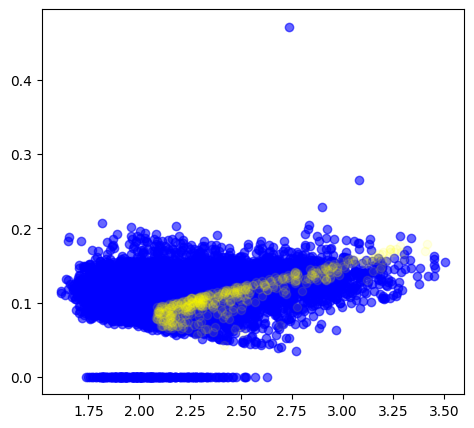

In [6]:
log_size_sim = np.log10(df_simulation_599['size'])

log_size1 = np.log10(source_events['size'])
log_size2 = np.log10(antisource_events['size'])

plt.figure(figsize=(12, 5))

# График для width
plt.subplot(1, 2, 1)
plt.scatter(log_size_sim, df_simulation_599['width[0]'], color='blue', alpha=0.6, label='Width[0] - simulation') # simul
plt.scatter(log_size1, source_events['width'], color='yellow', alpha=0.1, label='Width1 - data')
plt.scatter(log_size2, antisource_events['width'], color='yellow', alpha=0.1, label='Width2 - data')

# Ограничение сверху для width
width_upper_limit = 0.068*log_size - 0.047
plt.plot(log_size, width_upper_limit, color='red', linestyle='--', label='Width Upper Limit')
plt.xlabel('log10(size)')
plt.ylabel('Width')
plt.title('Width vs log10(size)')
plt.legend()

# График для length
plt.subplot(1, 2, 2)
plt.scatter(log_size_sim, df_simulation_599['length[0]'], color='blue', alpha=0.6, label='Length[0] - simulation') # simul
plt.scatter(log_size1, source_events['length'], color='green', alpha=0.2, label='Length1 - data')
plt.scatter(log_size2, antisource_events['length'], color='green', alpha=0.2, label='Length2 - data')

# Ограничение сверху для length
length_upper_limit = 0.145 * log_size
plt.plot(log_size, length_upper_limit, color='red', linestyle='--', label='Length Upper Limit')
plt.xlabel('log10(size)')
plt.ylabel('Length')
plt.title('Length vs log10(size)')
plt.legend()

plt.tight_layout()
plt.show()

### Гистограмма по тета

/tmp/ipykernel_4731/4092745934.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
/tmp/ipykernel_4731/4092745934.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 -


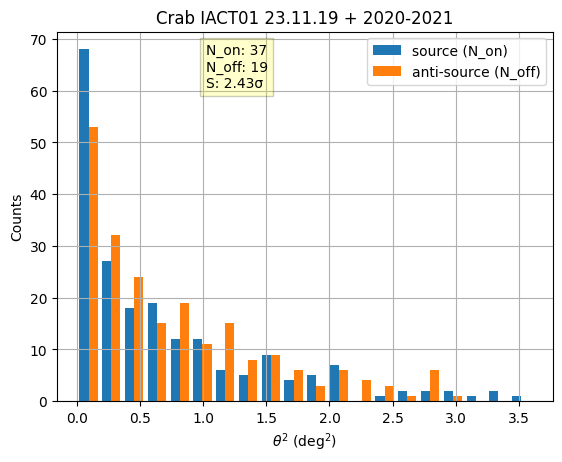

N_on = 37, N_off = 19, Significance = 2.43σ


In [7]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=20, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Crab IACT01 23.11.19 + 2020-2021')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.show()

print(f'N_on = {N_on}, N_off = {N_off}, Significance = {S}σ')

In [15]:
# Вычисляем разницу N_on - N_off для каждого бина θ²
theta_bins = np.linspace(0, max(df['theta2_signal'].max(), df['theta2_background'].max()), 20)
on_hist, _ = np.histogram(df['theta2_signal'], bins=theta_bins)
off_hist, _ = np.histogram(df['theta2_background'], bins=theta_bins)
diff_hist = on_hist - off_hist

# Строим гистограмму разницы
plt.bar(theta_bins[:-1], diff_hist, width=np.diff(theta_bins), align='edge', alpha=0.7)
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('N_on - N_off')
plt.title('Difference between On and Off regions')
plt.grid(True)
plt.show()

NameError: name 'df' is not defined

### Гистограмма по alpha

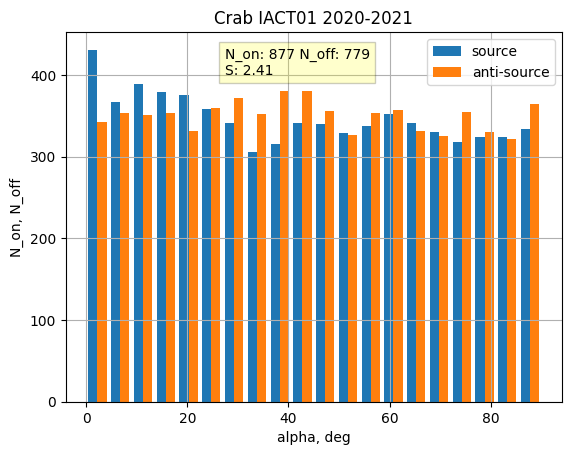

N_on = 877 N_off = 779 S_lima = 2.41


In [8]:
def filter_hillas_data(df):
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['delta_time'] < 0.5) &
        (df['error_deg'] < 0.1) &
        (df['size'] > 120) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source' 
    
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 2020-2021') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)

N_on = 431.0 N_off = 342.0 3.2011075056319482 3.2


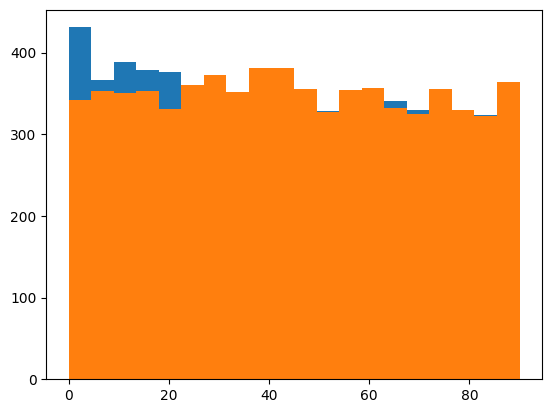

In [9]:
# Пашин В. вариант по альфа
# table_had = pd.read_csv('/media/alexandra/DATA/IACT01_231119/231119.01_out_hillas_14_7.0fix.csv') #23.11.19
table_had = hillas

on10 = plt.hist(table_had['alpha1'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist1'] > 0.36) & 
                      (table_had['dist1'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
off10 = plt.hist(table_had['alpha2'][(table_had['CR_portion']/np.cos(np.pi/2-np.pi*table_had['tel_el']/180) > 5) & 
                      (table_had['delta_time'] < 0.5) &
                      (table_had['error_deg'] < 0.1) &
                      (table_had['size'] > 120) & 
                      (table_had['dist2'] > 0.36) & 
                      (table_had['dist2'] < 1.44) & 
                      (table_had['width'] > 0.024) & 
                      (table_had['width'] < (0.068*np.log10(table_had['size'])-0.047)) &
                      (table_had['length'] <0.145*np.log10(table_had['size']))], range=[0,90], bins=20)[0]
N_on = on10[0]
N_off = off10[0]
S_lima = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
print('N_on =', on10[0], 'N_off =', off10[0], (on10[0] - off10[0])/np.sqrt(on10[0] + off10[0]), S_lima)

### Пытаемся пересчитать параметры для 4 точек фона

In [12]:
# генерим точки и считаем дист, альфа
def add_background_points_columns(df):
    # Создаем копию DataFrame чтобы избежать предупреждений
    df = df.copy()
    
    # Координаты центра камеры
    center_x, center_y = 0, 0
    # Создаем новые столбцы для 4 фоновых точек
    for i in range(4):
        if i == 0:
            # Диаметрально противоположная точка
            bg_x = -df['source_x']
            bg_y = -df['source_y']
        elif i == 1:
            # Первая перпендикулярная точка (поворот на 90°)
            bg_x = -df['source_y']
            bg_y = df['source_x']
        elif i == 2:
            # Вторая перпендикулярная точка (поворот на -90°)
            bg_x = df['source_y']
            bg_y = -df['source_x']
        elif i == 3:
            # Точка с поворотом на 45°
            bg_x = (df['source_x'] - df['source_y'])/np.sqrt(2)
            bg_y = (df['source_x'] + df['source_y'])/np.sqrt(2)
        
        # Вычисляем параметры для каждой фоновой точки
        delta_x = bg_x - df['Xc']
        delta_y = bg_y - df['Yc']
        dist = np.sqrt(delta_x**2 + delta_y**2)
        
        # Направление главной оси
        u_x = np.cos(np.radians(df['alpha1']))
        u_y = np.sin(np.radians(df['alpha1']))
        
        # Вычисляем угол alpha
        dot = delta_x * u_x + delta_y * u_y
        alpha = np.arccos(np.clip(dot / dist, -1, 1))
        alpha_deg = np.rad2deg(alpha)
        
        # Добавляем новые столбцы в DataFrame
        df[f'bg{i+1}_x'] = bg_x
        df[f'bg{i+1}_y'] = bg_y
        df[f'bg{i+1}_dist'] = dist
        df[f'bg{i+1}_alpha'] = alpha_deg
    
    return df

# Применяем функцию к данным
hillas_with_background = add_background_points_columns(df_19)

# Проверяем результат
print(hillas_with_background.head())

   por  event_numb                  time         unix_time_ns  delta_time  \
0    1          14  15:59:01:558:835:010  1574524741558835010        0.44   
1    1          24  15:59:01:633:642:980  1574524741633642980        0.37   
2    1          28  15:59:01:654:668:020  1574524741654668020        0.35   
3    1          30  15:59:01:669:731:650  1574524741669731650        0.33   
4    1          40  15:59:01:704:527:060  1574524741704527060        0.30   

   error_deg     tel_az  tel_el  source_az  source_el  ...  bg2_dist  \
0       0.03  118.64135  47.181  120.08002     47.882  ...  2.268964   
1       0.03  118.64135  47.181  120.08002     47.882  ...  2.913490   
2       0.03  118.64135  47.181  120.08002     47.882  ...  3.088953   
3       0.03  118.64135  47.181  120.08002     47.882  ...  1.731582   
4       0.03  118.64135  47.181  120.08002     47.882  ...  4.011269   

    bg2_alpha  bg3_x  bg3_y  bg3_dist   bg3_alpha     bg4_x    bg4_y  \
0   90.853643  -0.71  -0.99  2.0

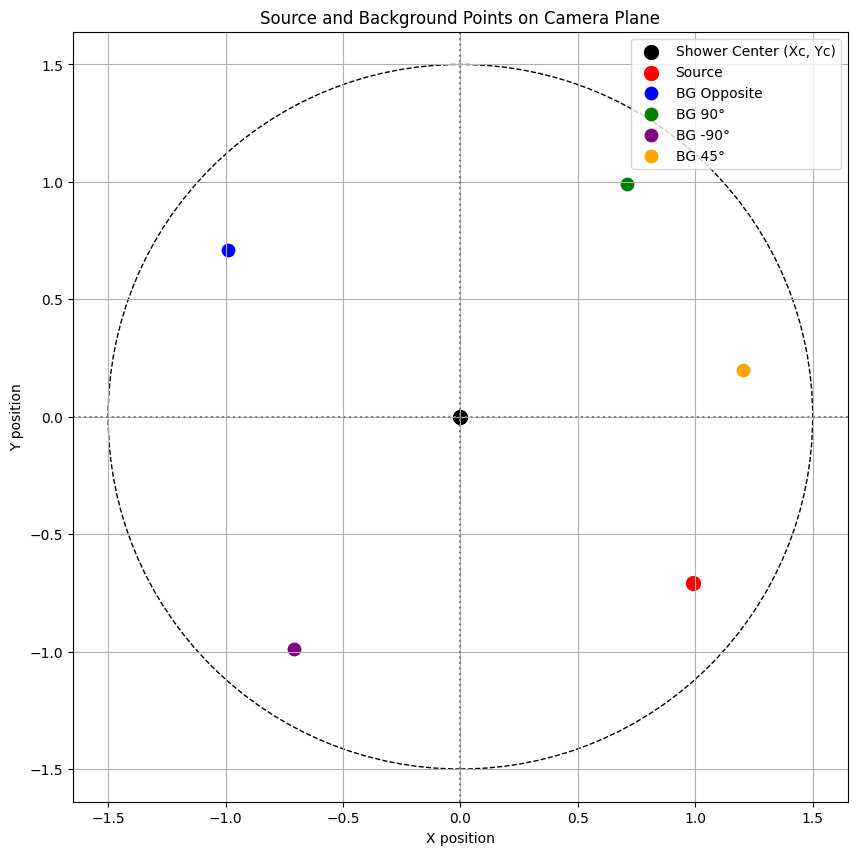

In [13]:
#рисуем выбранные точки
def plot_points_on_circle(df_sample):
    plt.figure(figsize=(10, 10))
    
    # Окружность камеры
    circle = plt.Circle((0, 0), 1.5, fill=False, color='black', linestyle='--')
    plt.gca().add_patch(circle)
    
    # Центр события (Xc, Yc)
    plt.scatter(0, 0, color='black', s=100, label='Shower Center (Xc, Yc)')
    
    # Точка источника
    plt.scatter(df_sample['source_x'], df_sample['source_y'], 
                color='red', s=100, label='Source')
    
    # Фоновые точки
    colors = ['blue', 'green', 'purple', 'orange']
    labels = ['Opposite', '90°', '-90°', '45°']
    
    for i in range(4):
        plt.scatter(df_sample[f'bg{i+1}_x'], df_sample[f'bg{i+1}_y'],
                    color=colors[i], s=80, label=f'BG {labels[i]}')
    
    # Настройки графика
    plt.axhline(0, color='gray', linestyle=':')
    plt.axvline(0, color='gray', linestyle=':')
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.title('Source and Background Points on Camera Plane')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Выбираем одно событие для визуализации
sample_event = hillas_with_background.iloc[0]  # Первое событие
plot_points_on_circle(sample_event)

In [14]:
# применяем каты
source_events_test, antisource_events_6_points = filter_hillas_data(hillas_with_background)
antisource_events_6_points

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg2_alpha,bg3_x,bg3_y,bg3_dist,bg3_alpha,bg4_x,bg4_y,bg4_dist,bg4_alpha,source_type
143,1,2805,15:59:15:694:170:230,1574524755694170230,0.19,0.03,118.70505,47.212,120.14370,47.912,...,38.835958,-0.71,-0.99,1.165603,162.755655,1.202082,0.197990,1.852134,69.059460,anti-source
284,1,5427,15:59:28:817:664:770,1574524768817664770,0.18,0.03,118.76233,47.243,120.20744,47.943,...,5.268953,-0.71,-0.99,1.936563,77.052165,1.202082,0.197990,2.749231,22.934968,anti-source
2416,2,32527,16:02:59:790:376:570,1574524979790376570,0.21,0.03,119.74931,47.715,121.21124,48.411,...,93.912799,-0.71,-0.99,2.441613,174.529196,1.202082,0.197990,1.634708,111.065515,anti-source
3169,3,38332,16:04:19:892:378:820,1574525059892378820,0.39,0.03,120.12314,47.897,121.59318,48.586,...,47.520926,-0.70,-0.99,1.513666,102.535924,1.195010,0.205061,3.218806,64.098494,anti-source
4658,4,49475,16:06:51:917:965:540,1574525211917965540,0.42,0.03,120.84381,48.230,122.32923,48.919,...,105.761611,-0.70,-1.00,2.438725,174.849601,1.202082,0.212132,1.768239,122.684272,anti-source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203892,136,1977376,20:58:59:304:133:170,1574542739304133170,0.20,0.03,238.72920,48.449,237.21961,49.120,...,141.167863,-0.70,1.00,3.120381,168.163162,-0.212132,-1.202082,3.180981,149.903817,anti-source
204464,137,1981434,21:00:11:056:770:090,1574542811056770090,0.06,0.03,239.07097,48.280,237.56901,48.965,...,174.682472,-0.71,1.00,2.489218,115.253750,-0.205061,-1.209153,2.381182,170.657417,anti-source
205056,137,1985258,21:01:12:396:970:200,1574542872396970200,0.40,0.03,239.36333,48.143,237.86575,48.831,...,115.276651,-0.72,1.00,1.331169,60.890014,-0.197990,-1.216224,1.134473,164.393935,anti-source
205821,138,1990529,21:02:43:038:505:770,1574542963038505770,0.04,0.03,239.79564,47.936,238.30611,48.632,...,166.076620,-0.72,1.00,1.413737,123.440159,-0.197990,-1.216224,2.867341,175.037428,anti-source


In [15]:
# вычисляем тета для точек фона
def calculate_theta2_for_all_background(df):
    # Функция для расчета ksi (как в вашем примере)
    def calculate_ksi(rc, size):
        if rc < 7.5:
            return 1.3
        elif 7.5 <= rc <= 10:
            return 1.6
        elif rc > 10:
            if size < 700:
                return 2.0
            elif 700 <= size < 1000:
                return 1.9
            elif 1000 <= size < 1250:
                return 1.75
            elif 1250 <= size < 1500:
                return 1.5
        return np.nan

    # Создаем копию DataFrame
    df = df.copy()
    
    # Для каждой из 5 фоновых точек
    for i in range(1, 5):
        # Вычисляем rc (переводим расстояние в см)
        rc_col = f'bg{i}_rc'
        df[rc_col] = df[f'bg{i}_dist'] / 0.1206
        
        # Вычисляем ksi для каждой точки
        ksi_col = f'bg{i}_ksi'
        df[ksi_col] = df.apply(lambda row: calculate_ksi(row[rc_col], row['size']), axis=1)
        
        # Вычисляем disp (смещение)
        disp_col = f'bg{i}_disp'
        df[disp_col] = df[ksi_col] * (1.0 - df['width'] / df['length'])
        
        # Вычисляем theta²
        theta2_col = f'bg{i}_theta2'
        df[theta2_col] = (df[disp_col]**2 + df[f'bg{i}_dist']**2 - 2 * df[disp_col] * df[f'bg{i}_dist'] * np.cos(np.radians(df[f'bg{i}_alpha']))
        )
    
    # Удаляем промежуточные столбцы (если не нужны)
    cols_to_drop = [f'bg{i}_{param}' for i in range(1,5) for param in ['rc', 'ksi', 'disp']]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    return df

# Применяем функцию к данным
hillas_with_theta2 = calculate_theta2_for_all_background(antisource_events_6_points)

# Проверяем результат
print(hillas_with_theta2)

        por  event_numb                  time         unix_time_ns  \
143       1        2805  15:59:15:694:170:230  1574524755694170230   
284       1        5427  15:59:28:817:664:770  1574524768817664770   
2416      2       32527  16:02:59:790:376:570  1574524979790376570   
3169      3       38332  16:04:19:892:378:820  1574525059892378820   
4658      4       49475  16:06:51:917:965:540  1574525211917965540   
...     ...         ...                   ...                  ...   
203892  136     1977376  20:58:59:304:133:170  1574542739304133170   
204464  137     1981434  21:00:11:056:770:090  1574542811056770090   
205056  137     1985258  21:01:12:396:970:200  1574542872396970200   
205821  138     1990529  21:02:43:038:505:770  1574542963038505770   
206528  138     1995005  21:03:56:986:529:370  1574543036986529370   

        delta_time  error_deg     tel_az  tel_el  source_az  source_el  ...  \
143           0.19       0.03  118.70505  47.212  120.14370     47.912  ...   
2

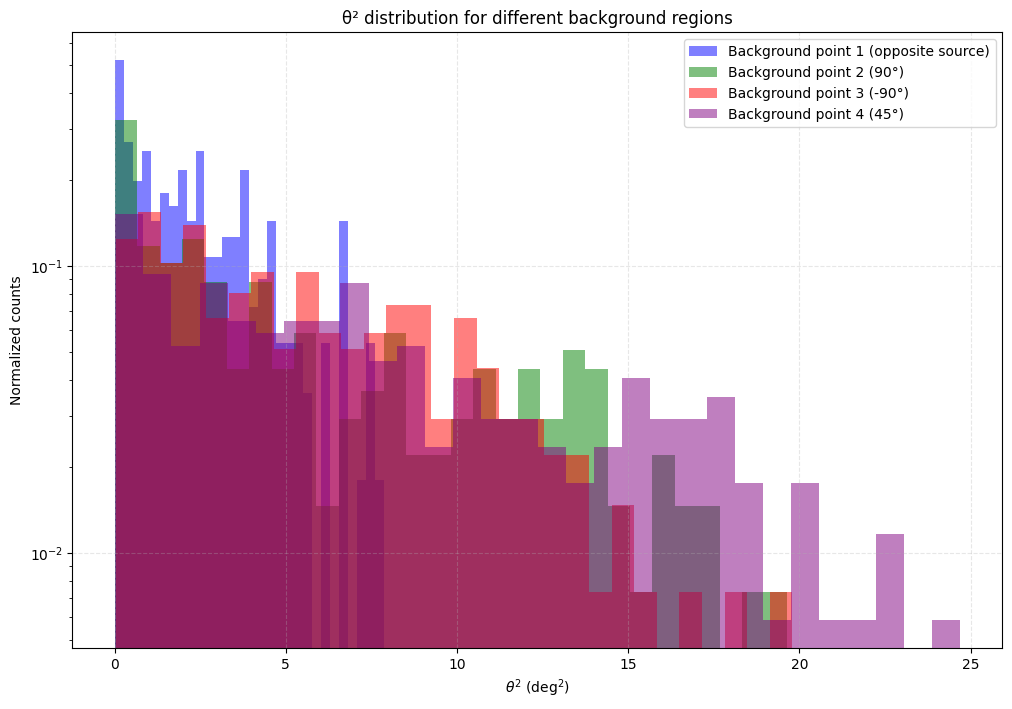

In [17]:
def plot_all_theta2_histograms(df, bins=40):
    plt.figure(figsize=(12, 8))
    
    # Цвета для разных фоновых точек
    colors = ['blue', 'green', 'red', 'purple', 'orange']
    labels = ['Background point 1 (opposite source)', 
              'Background point 2 (90°)', 
              'Background point 3 (-90°)', 
              'Background point 4 (45°)']
    
    # Проверяем какие фоновые точки есть в данных
    available_points = [i for i in range(1,6) if f'bg{i}_theta2' in df.columns]
    
    if not available_points:
        raise ValueError("No background theta2 columns found in DataFrame!")
    
    # Строим гистограммы для каждой точки
    for i, color, label in zip(available_points, colors, labels):
        theta2 = df[f'bg{i}_theta2'].values
        
        plt.hist(theta2, bins=bins,
                 alpha=0.5, color=color, label=label, 
                 histtype='stepfilled', density=True)
    
    # Настройки графика
    plt.xlabel(r'$\theta^2$ (deg$^2$)')
    plt.ylabel('Normalized counts')
    plt.title(f'θ² distribution for different background regions')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.yscale('log')  # Логарифмическая шкала для y (опционально)
    
    plt.show()

# Использование функции
plot_all_theta2_histograms(hillas_with_theta2,bins=30)

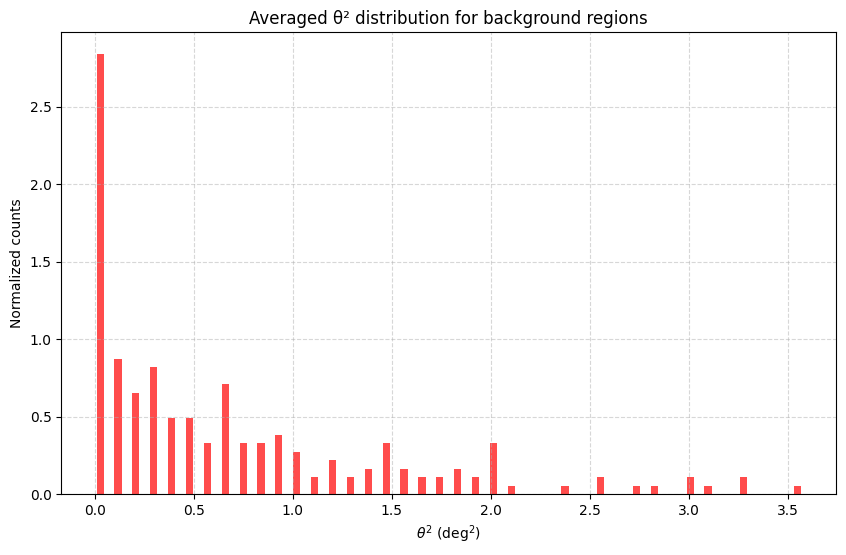

In [57]:
#заготовка нерабочая
df = hillas_with_theta2
    # Собираем все theta2 фоновых точек в один массив
all_bg_theta2 = np.concatenate([
    df['bg1_theta2'].values,
    df['bg2_theta2'].values,
    df['bg3_theta2'].values,
    df['bg4_theta2'].values,
    df['bg5_theta2'].values
])

# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist([source_events['theta2'],np.mean(all_bg_theta2)], 
                                bins=40, 
                                density=True,
                                alpha=0.7,
         color=['red', 'blue'],
         label=['Source', 'Background'])

plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Normalized counts')
plt.title('Averaged θ² distribution for background regions')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

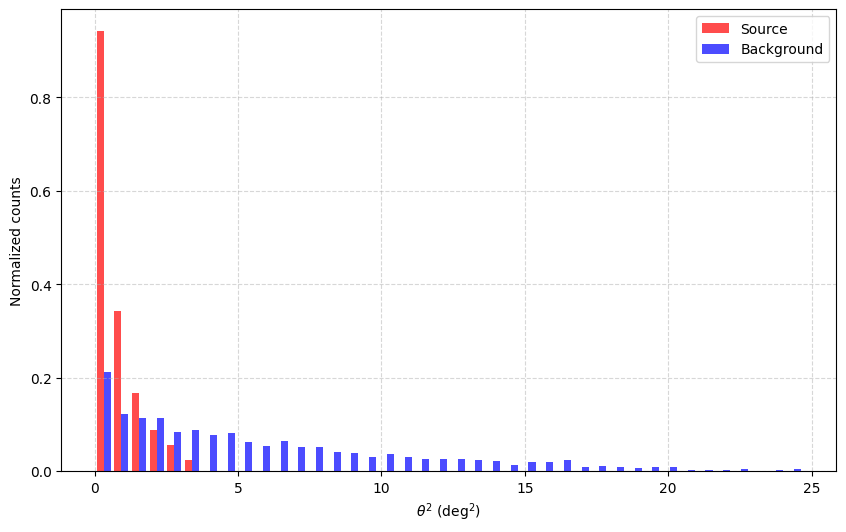

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Собираем все theta2 фоновых точек
all_bg_theta2 = np.concatenate([
    df['bg1_theta2'].values,
    df['bg2_theta2'].values,
    df['bg3_theta2'].values,
    df['bg4_theta2'].values,
    df['bg5_theta2'].values
])

# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist([source_events['theta2'], all_bg_theta2], 
         bins=40, 
         density=True,
         alpha=0.7,
         color=['red', 'blue'],
         label=['Source', 'Background'])

plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Normalized counts')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [16]:
# Пашин вариант
def add_background_alphas_and_dists(df):
    """
    Добавляет в DataFrame alpha3–alpha6 и dist3–dist6 для дополнительных фоно-точек,
    расположенных равномерно по окружности вокруг (0,0), с ориентацией эллипса, восстановленной по alpha1 и alpha2.
    """

    df = df.copy()

    # Вектор на источник
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    r_norm = np.sqrt(dx**2 + dy**2)
    r_unit_x = dx / r_norm
    r_unit_y = dy / r_norm

    # Определяем направление главной оси: если alpha1 < alpha2, то ось ближе к источнику
    angle_sign = np.where(df['alpha1'] < df['alpha2'], -1, 1)

    # Поворачиваем r_unit на ±alpha1 (в радианах)
    alpha_rad = np.deg2rad(df['alpha1']) * angle_sign
    u_x = r_unit_x * np.cos(alpha_rad) - r_unit_y * np.sin(alpha_rad)
    u_y = r_unit_x * np.sin(alpha_rad) + r_unit_y * np.cos(alpha_rad)

    # Углы для новых точек фона (в градусах)
    angles_deg = [60, 120, 240, 300]

    for i, angle in enumerate(angles_deg, start=3):
        # Повернуть вектор источника (от [0,0]) на угол
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        bg_x = df['source_x'] * cos_a - df['source_y'] * sin_a
        bg_y = df['source_x'] * sin_a + df['source_y'] * cos_a

        # Вектор от центра эллипса до новой точки
        delta_x = bg_x - df['Xc']
        delta_y = bg_y - df['Yc']
        dist = np.sqrt(delta_x**2 + delta_y**2)

        # Скалярное произведение для угла между главной осью и направлением на фоновую точку
        dot = delta_x * u_x + delta_y * u_y
        alpha = np.arccos(np.clip(dot / dist, -1, 1))
        alpha_deg = np.rad2deg(alpha)

        df[f'dist{i}'] = dist
        df[f'alpha{i}'] = alpha_deg

    return df

# Считаем альфы и дисты для точек фона и записываем в датафрейм
exp_data_5_points = add_background_alphas_and_dists(hillas)

# Для всех пар alphaX-distX считаем theta2 и заносим в датафрейм
for i in range(1, 7):
    exp_data_5_points[f'theta2_{i}'] = exp_data_5_points.apply(
        lambda row: calculate_theta2_classic(
            row.get(f'dist{i}', np.nan),
            row['size'],
            row['width'],
            row['length'],
            row.get(f'alpha{i}', np.nan)
        ),
        axis=1
    )
    
# Функция для отрисовки
def plot_theta2_distribution_with_background_average(exp_data, prefix=''):
    """Построение theta² с усреднением по фоновым точкам."""
    bins = np.linspace(0, 5, 20)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Сигнальные данные
    on_data = exp_data['theta2_1']
    N_on, _ = np.histogram(on_data, bins=bins)

    # Список фоновых theta2
    bg_cols = [f'theta2_{i}' for i in range(2, 7)]
    N_off_all = []

    for col in bg_cols:
        data = exp_data[col]
        hist, _ = np.histogram(data, bins=bins)
        N_off_all.append(hist)

    # Усреднённая гистограмма фона
    N_off_avg = np.mean(N_off_all, axis=0)

    # Рисуем
    bar_width = 0.1
    plt.figure(figsize=(8, 5))
    plt.bar(bin_centers - bar_width/2, N_on, width=bar_width, label='source', color='dodgerblue')
    plt.bar(bin_centers + bar_width/2, N_off_avg, width=bar_width, label='background avg 5 points', color='orange')

    plt.xlabel(r'$\theta^2$ (deg$^2$)')
    plt.ylabel('Counts')
    plt.legend()
    plt.title('Theta² distribution with background average')
    plt.tight_layout()
    plt.savefig('plots2/theta2_comp_avg_' + prefix + '.png')
    plt.show()

    plt.figure(figsize=(8, 5))

    # Разность
    diff = N_on - N_off_avg
    plt.plot(bin_centers, diff, marker='o', linestyle='-', label='N_on - N_off', color='black')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel("Theta²")
    plt.ylabel("N_on - N_off")
    plt.title("Excess (ON - OFF)")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    
    N_on_total = N_on.sum()
    N_off_total = N_off_avg.sum()
    # Захардкожено для 5 точек фона
    try:
        S_lima = round(
            np.sqrt(
                2 * N_on_total * np.log(6 * (N_on_total / (N_on_total + N_off_total))) +
                2 * N_off_total * np.log(1.2 * (N_off_total / (N_on_total + N_off_total)))
            ), 2
        )
    except:
        S_lima = np.nan
    
    plt.figtext(0.15, 0.01, f"N_on = {N_on_total}, N_off = {N_off_total}, S = {S_lima}")
    plt.tight_layout()
    plt.savefig('plots2/theta_diff_points_with_sigma' + prefix + '.png')
    plt.show()

NameError: name 'calculate_theta2_classic' is not defined

In [13]:
# кат только по дист1? ок или не?
# суммарно 19 год добавить (после того, как Паша обработает)
# для тета: сгенерить 4 точки фона
# эффективную площадь построить